# About This Notebook
This notebook analyzes CVE data for the selected month. Please ensure the data file is up to date before running. Run all cells in order for best results.

## February 2026 CVE Data

In [1]:
# ===== DATE CONFIGURATION =====
# UPDATE THESE VALUES WHEN CREATING NEW MONTHLY NOTEBOOKS
ANALYSIS_YEAR = 2026
ANALYSIS_MONTH = 2  # February = 1
MONTH_NAME = "February"

# ===== IMPORTS AND SETUP =====
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown
from datetime import date
import calplot
import glob
import json
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pyarrow  # Pandas 3: PyArrow backend for faster string operations
import warnings

# Register a cell magic for Markdown
@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

# Configure logging and warnings
logging.getLogger('matplotlib.font_manager').disabled = True
warnings.filterwarnings("ignore")

# Set pandas display options
pd.set_option('display.width', 500)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 10)

# Set the path to the shared data file
data_path = '../../data/nvd.jsonl'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at {data_path}. Please run 'python ../../download_data.py' to download the latest data.")

In [2]:
def get_nested_value(entry, keys, default='Missing_Data'):
    try:
        for key in keys:
            entry = entry[key]
        return entry
    except (KeyError, IndexError):
        return default

# ===== CALCULATE DATE RANGES BASED ON CONFIGURATION =====
from calendar import monthrange

# Calculate start and end dates for the analysis month
start_date_str = f"{ANALYSIS_YEAR}-{ANALYSIS_MONTH:02d}-01"
if ANALYSIS_MONTH == 12:
    end_year = ANALYSIS_YEAR + 1
    end_month = 1
else:
    end_year = ANALYSIS_YEAR
    end_month = ANALYSIS_MONTH + 1
end_date_str = f"{end_year}-{end_month:02d}-01"

# Get number of days in the analysis month
days_in_month = monthrange(ANALYSIS_YEAR, ANALYSIS_MONTH)[1]

print(f"Analyzing {MONTH_NAME} {ANALYSIS_YEAR}")
print(f"Date range: {start_date_str} to {end_date_str}")
print(f"Days in month: {days_in_month}")

row_accumulator = []
# Use data_path instead of glob.glob
with open(data_path, 'r', encoding='utf-8') as f:
    nvd_data = json.load(f)
    for entry in nvd_data:
        new_row = {
            'CVE': get_nested_value(entry, ['cve', 'id']),
            'Published': get_nested_value(entry, ['cve', 'published']),
            'AttackVector': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'attackVector']),
            'AttackComplexity': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'attackComplexity']),
            'PrivilegesRequired': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'privilegesRequired']),
            'UserInteraction': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'userInteraction']),
            'Scope': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'scope']),
            'ConfidentialityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'confidentialityImpact']),
            'IntegrityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'integrityImpact']),
            'AvailabilityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'availabilityImpact']),
            'BaseScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'baseScore'], '0.0'),
            'BaseSeverity': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'baseSeverity']),
            'ExploitabilityScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'exploitabilityScore']),
            'ImpactScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'impactScore']),
            'CWE': get_nested_value(entry, ['cve', 'weaknesses', 0, 'description', 0, 'value']),
            'Description': get_nested_value(entry, ['cve', 'descriptions', 0, 'value'], ''),
            'Assigner': get_nested_value(entry, ['cve', 'sourceIdentifier']),
            'Tag': get_nested_value(entry, ['cve', 'cveTags', 0, 'tags'], np.nan),
            'Status': get_nested_value(entry, ['cve', 'vulnStatus'], '')
        }
        row_accumulator.append(new_row)

nvd = pd.DataFrame(row_accumulator)
# Only filter on Status if the column exists
if 'Status' in nvd.columns:
    nvd = nvd[~nvd.Status.str.contains('Rejected')]

nvd['Published'] = pd.to_datetime(nvd['Published'])

# Filter data for the analysis period using calculated dates
startdate_pd = pd.Timestamp(start_date_str)
enddate_pd = pd.Timestamp(end_date_str)
nvd = nvd[(nvd['Published'] >= startdate_pd) & (nvd['Published'] < enddate_pd)]
nvd = nvd.sort_values(by=['Published'])
nvd = nvd.reset_index(drop=True)

nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore'])
nvd['BaseScore'] = nvd['BaseScore'].replace(0, np.nan)

nvdcount = nvd['Published'].count()
nvdunique = nvd['Published'].nunique()

# Calculate per-day average
per_day = nvdcount / days_in_month

print(f"Total CVEs found: {nvdcount}")
print(f"Average CVEs per day: {per_day:.2f}")
print(f"Average CVSS Score: {nvd['BaseScore'].mean().round(2)}")


Analyzing February 2026
Date range: 2026-02-01 to 2026-03-01
Days in month: 28


Total CVEs found: 4619
Average CVEs per day: 164.96
Average CVSS Score: 6.8


In [3]:
Markdown(f"## CVE Graphs")

## CVE Graphs

In [4]:
Month_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("M")).agg('count')
Year_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("Y")).agg('count')
Week_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("W")).agg('count')
Day_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("D")).agg('count')

In [5]:
Markdown(f"### CVE Calendar")

### CVE Calendar

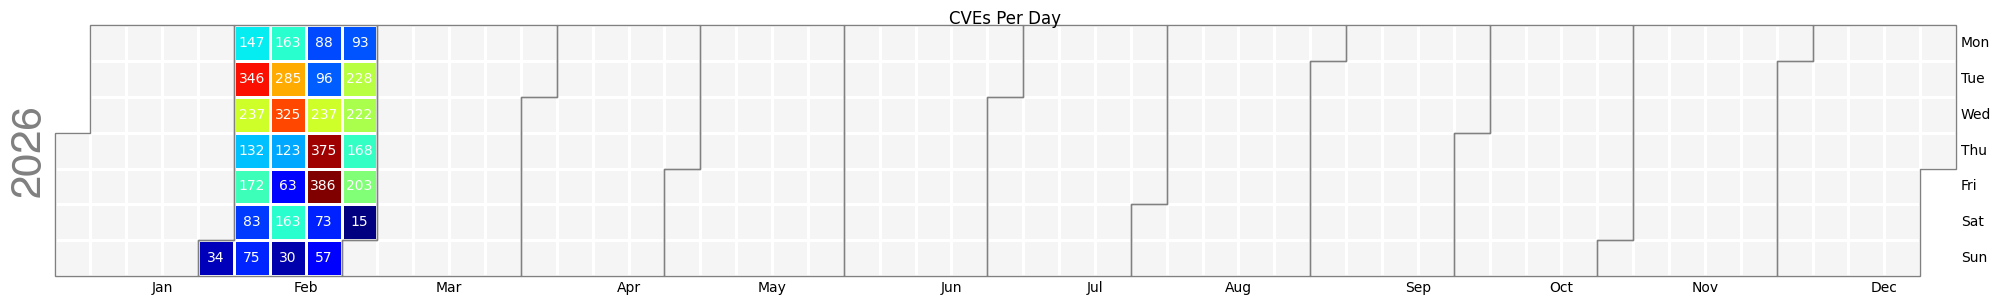

In [6]:
dfs = nvd['Published'].apply(lambda x: pd.to_datetime(x, errors='coerce', format='%Y/%m/%d'))
df = dfs.value_counts()
df = df.to_frame()
df.index = df.index.strftime('%m/%d/%Y')
df.index = pd.to_datetime(df.index, format='%m/%d/%Y')
calplot.calplot(df.T.squeeze(), cmap='jet', dropzero=True, edgecolor="Grey", textcolor="White", textformat='{:.0f}', textfiller='', suptitle='CVEs Per Day', figsize=(25,3));

In [7]:
Markdown(f"### CVE Per Week Graph")

### CVE Per Week Graph

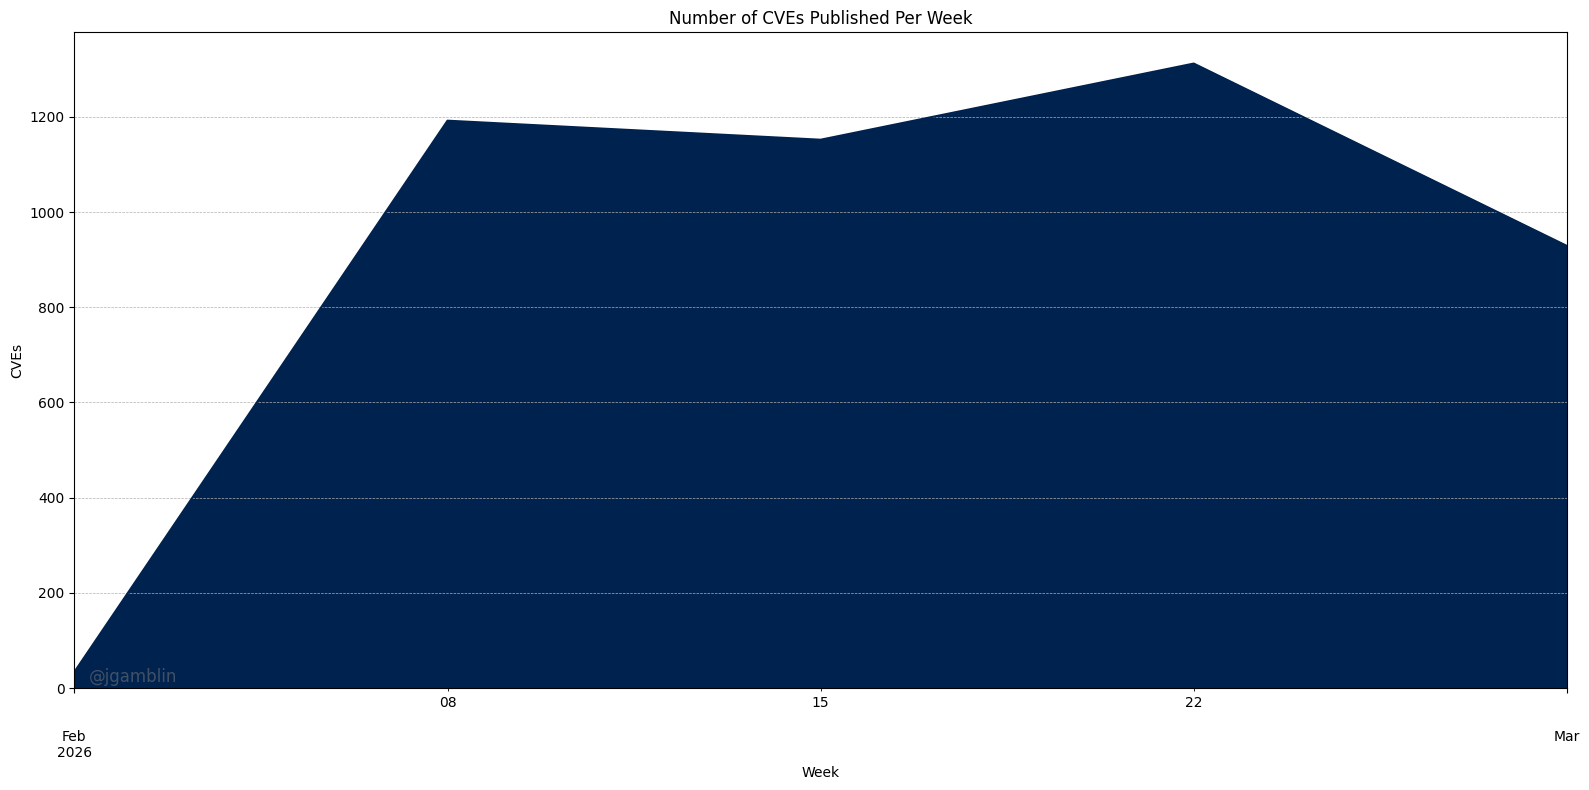

In [8]:
cg = Week_Graph.plot.area(colormap='cividis', figsize=(16, 8), title='Number of CVEs Published Per Week')
plt.grid(True, linestyle='--', linewidth=0.5)
cg.set_ylabel("CVEs")
cg.set_xlabel("Week")

# Add watermark
plt.text(0.01, 0.01, '@jgamblin', transform=cg.transAxes, fontsize=12, color='gray', alpha=0.5)

# Adjust layout and save the chart as a PNG file one directory up
plt.tight_layout()

plt.show()

In [9]:
Markdown(f"### CVE Per Day Graph")

### CVE Per Day Graph

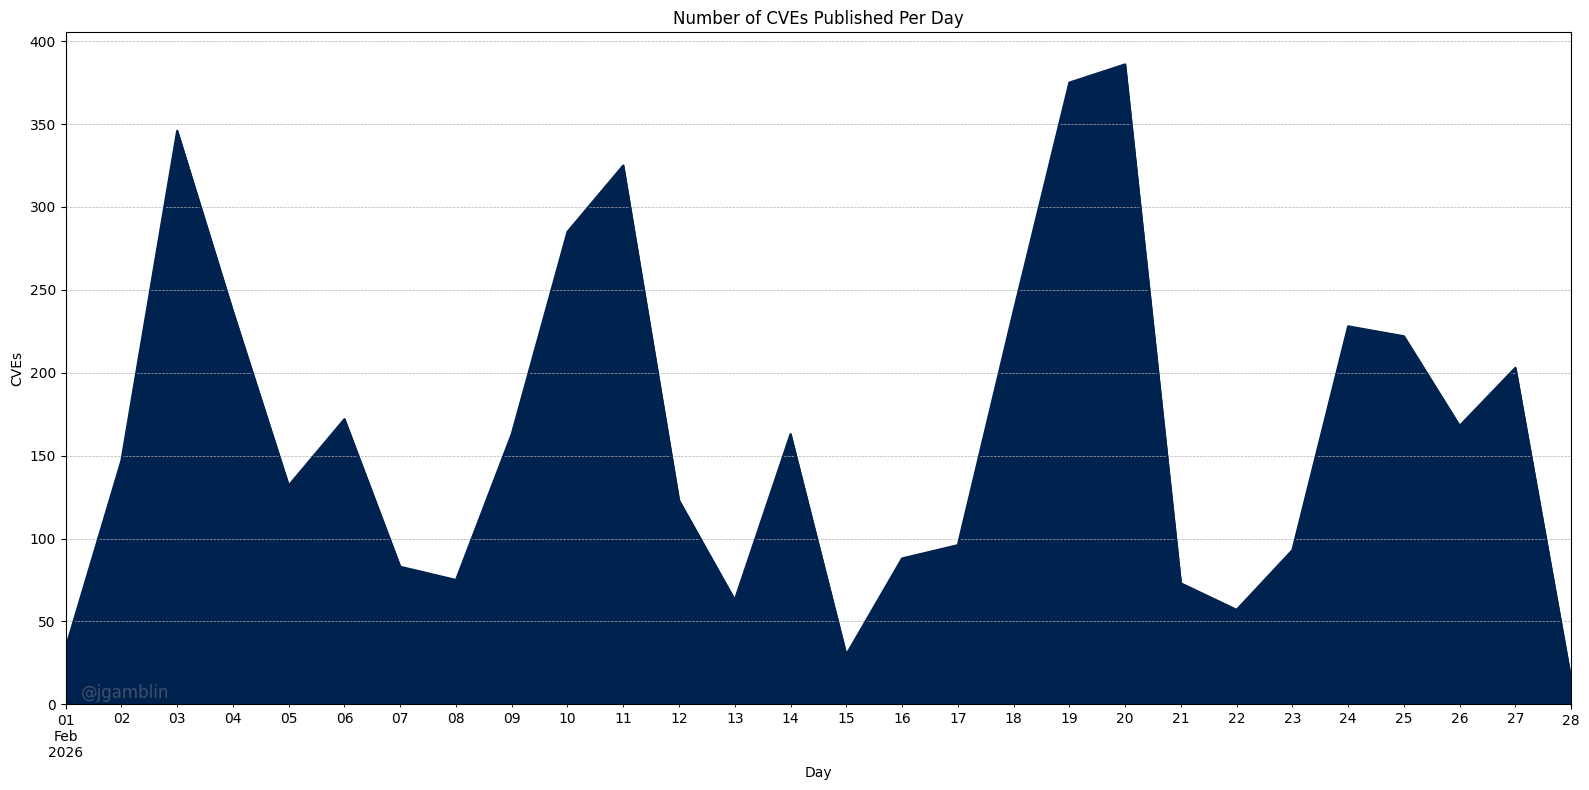

In [10]:
cg = Day_Graph.plot.area(colormap='cividis', figsize=(16, 8), title='Number of CVEs Published Per Day')
plt.grid(True, linestyle='--', linewidth=0.5)
cg.set_ylabel("CVEs")
cg.set_xlabel("Day")

# Add watermark
plt.text(0.01, 0.01, '@jgamblin', transform=cg.transAxes, fontsize=12, color='gray', alpha=0.5)

# Adjust layout and show the chart
plt.tight_layout()
plt.show()

In [11]:
Markdown(f"## CVSS Data")

## CVSS Data

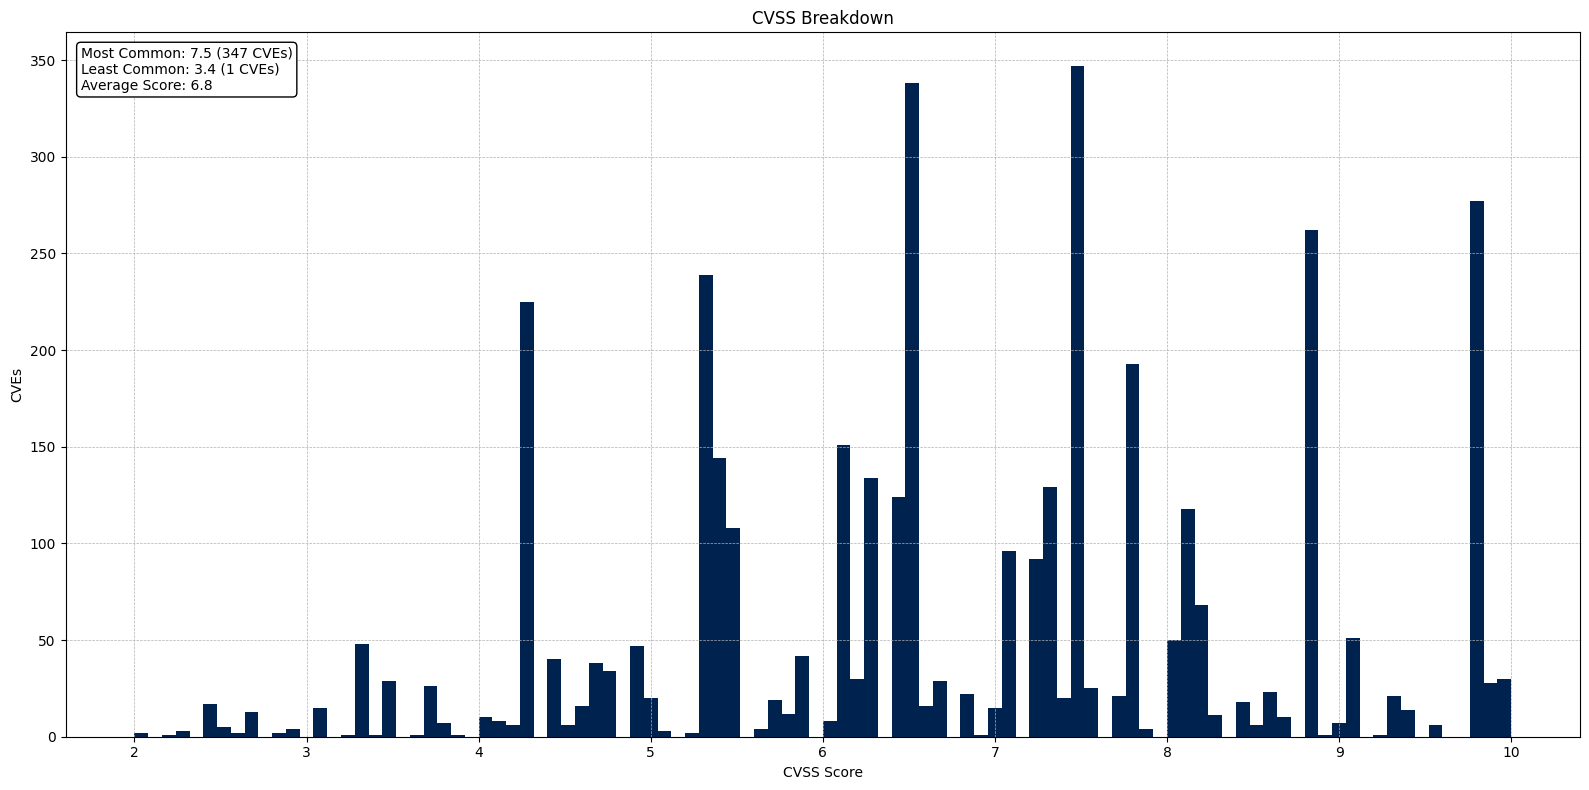

In [12]:
nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore'])
nvd['BaseScore'] = nvd['BaseScore'].replace(0, np.nan)

# Plot the CVSS breakdown with 100 bins
cg = nvd['BaseScore'].plot(kind="hist", bins=100, title='CVSS Breakdown', colormap='cividis', figsize=(16, 8))
plt.grid(True, linestyle='--', linewidth=0.5)
cg.set_ylabel("CVEs")
cg.set_xlabel("CVSS Score")

# Find the most common, least common, and average CVSS scores
most_common_score = nvd['BaseScore'].mode()[0]
least_common_score = nvd['BaseScore'].value_counts().idxmin()
most_common_count = nvd['BaseScore'].value_counts().max()
least_common_count = nvd['BaseScore'].value_counts().min()
average_score = nvd['BaseScore'].mean().round(2)

# Add annotation for the most common, least common, and average CVSS scores
annotation_text = (f'Most Common: {most_common_score} ({most_common_count} CVEs)\n'
                   f'Least Common: {least_common_score} ({least_common_count} CVEs)\n'
                   f'Average Score: {average_score}')
plt.text(0.01, 0.98, annotation_text, transform=cg.transAxes, fontsize=10, color='black',
         verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white'))

# Adjust layout and save the chart as a PNG file one directory up
plt.tight_layout()
plt.show()

In [13]:
Markdown(f"## CNA Data")

## CNA Data

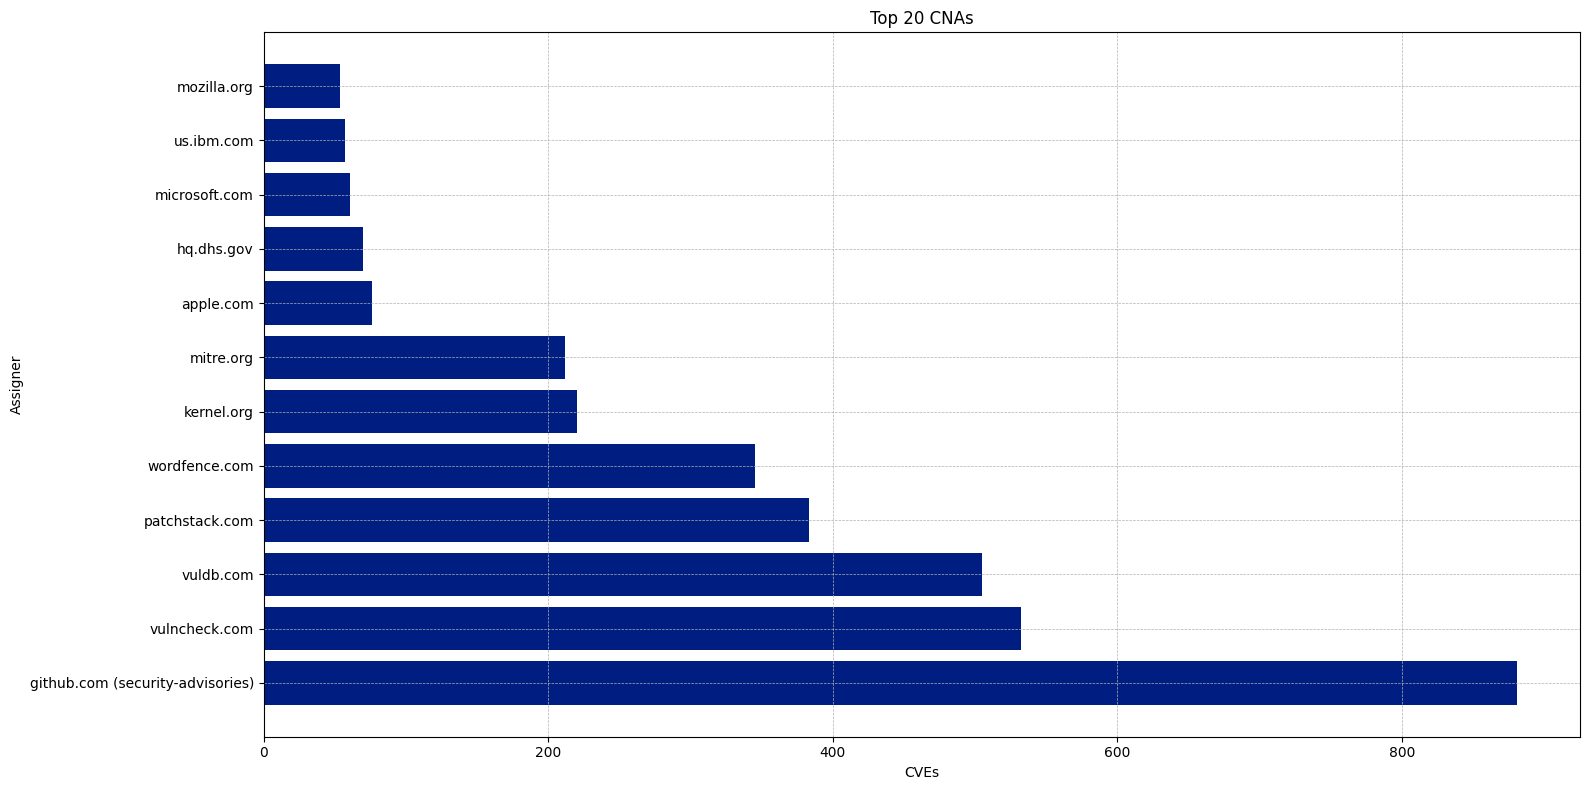

In [14]:
import matplotlib.pyplot as plt

# Replace specific assigner ID with email
nvd['Assigner'] = nvd['Assigner'].replace('416baaa9-dc9f-4396-8d5f-8c081fb06d67', 'cve@kernel.org')

# Extract domain names and check for uniqueness
nvd['Domain'] = nvd['Assigner'].apply(lambda x: x.split('@')[-1])
domain_counts = nvd['Domain'].value_counts()

# Modify Assigner column based on domain uniqueness
unique_domains = nvd.groupby('Domain')['Assigner'].nunique()
nvd['Assigner'] = nvd.apply(lambda x: x['Domain'] if unique_domains[x['Domain']] == 1 else f"{x['Domain']} ({x['Assigner'].split('@')[0]})", axis=1)

# Calculate frequency of assigners
nvd_frequency = nvd['Assigner'].value_counts().reset_index()
nvd_frequency.columns = ['Assigner', 'counts']
nvd_frequency = nvd_frequency[nvd_frequency.counts > 50].head(50)

# Plot the top 20 CNAs
plt.figure(figsize=(16, 8))
plt.barh("Assigner", "counts", data=nvd_frequency, color="#001d82")
plt.xlabel("CVEs")
plt.ylabel("Assigner")
plt.title("Top 20 CNAs")
plt.grid(True, linestyle='--', linewidth=0.5)

# Adjust layout and show the chart
plt.tight_layout()
plt.show()

In [15]:
Markdown(f"## CWE Data")

## CWE Data

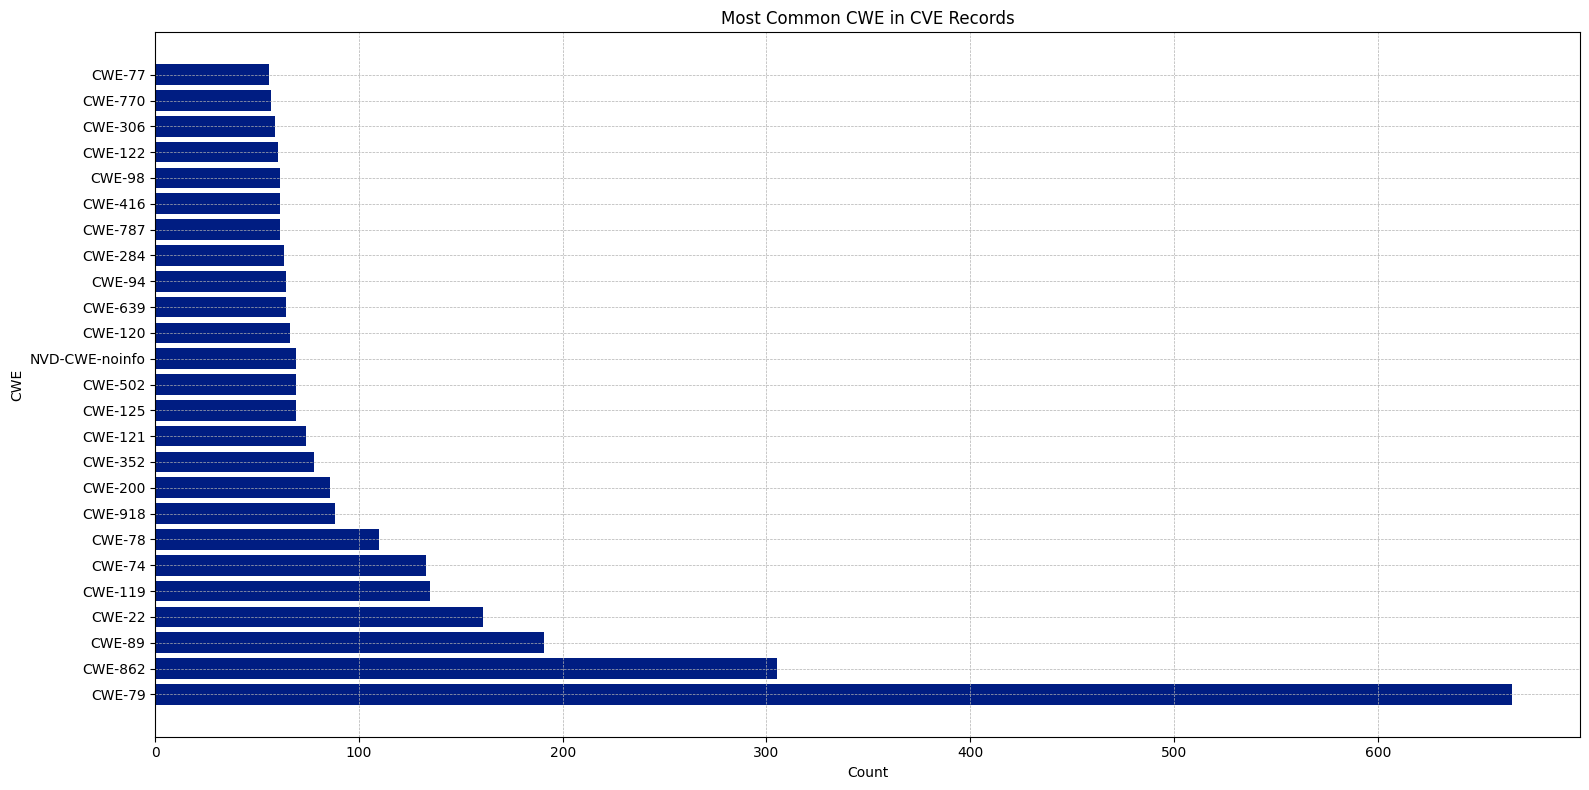

In [16]:
import matplotlib.pyplot as plt

# Calculate frequency of CWEs
nvd_cwe = nvd['CWE'].value_counts().reset_index()
nvd_cwe.columns = ['CWE', 'counts']
nvd_cwe = nvd_cwe[~nvd_cwe.CWE.str.contains('Missing_')]
nvd_cwe = nvd_cwe[nvd_cwe.counts > 20].head(25)

# Plot the most common CWEs
plt.figure(figsize=(16, 8))
plt.barh(nvd_cwe['CWE'], nvd_cwe['counts'], color="#001d82")
plt.xlabel("Count")
plt.ylabel("CWE")
plt.title("Most Common CWE in CVE Records")
plt.grid(True, linestyle='--', linewidth=0.5)

# Adjust layout and show the chart
plt.tight_layout()
plt.show()

In [17]:
Markdown(f"## More CVE Data")

## More CVE Data

In [18]:
Markdown(f"### Top CNA Assigner")

### Top CNA Assigner

In [19]:
nvd_frequency.style.hide()

Assigner,counts
github.com (security-advisories),881
vulncheck.com,532
vuldb.com,505
patchstack.com,383
wordfence.com,345
kernel.org,220
mitre.org,212
apple.com,76
hq.dhs.gov,70
microsoft.com,61


In [20]:
Markdown(f"### CVEs By Identifier")

### CVEs By Identifier

In [21]:
years = range(1999, 2027)
cve_counts = []

for year in years:
    count = len(nvd[nvd['CVE'].str.contains(f'CVE-{year}-')])
    if count > 0:
        cve_counts.append({'Year': year, 'Count': count})

cve_df = pd.DataFrame(cve_counts)
cve_df.style.hide(axis='index')

Year,Count
2018,3
2019,196
2020,157
2021,18
2022,15
2023,13
2024,47
2025,1098
2026,3072


In [22]:
Markdown(f"### First 5 CVEs")

### First 5 CVEs

In [23]:
nvd[["CVE", "Description"]].head(5).style.hide()

CVE,Description
CVE-2026-25069,"SunFounder Pironman Dashboard (pm_dashboard) version 1.3.13 and prior contain a path traversal vulnerability in the log file API endpoints. An unauthenticated remote attacker can supply traversal sequences via the filename parameter to read and delete arbitrary files. Successful exploitation can disclose sensitive information and delete critical system files, resulting in data loss and potential system compromise or denial of service."
CVE-2021-47856,Easy Cart Shopping Cart 2021 contains a non-persistent cross-site scripting vulnerability in the search module's keyword parameter. Remote attackers can inject malicious script code through the search input to compromise user sessions and manipulate application content.
CVE-2021-47885,Multiple payment terminal versions contain non-persistent cross-site scripting vulnerabilities in billing and payment information input fields. Attackers can inject malicious script code through vulnerable parameters to manipulate client-side requests and potentially execute session hijacking or phishing attacks.
CVE-2021-47908,Ultimate POS 4.4 contains a persistent cross-site scripting vulnerability in the product name parameter that allows remote attackers to inject malicious scripts. Attackers can exploit the vulnerability through product add or edit functions to execute arbitrary JavaScript and potentially hijack user sessions.
CVE-2021-47909,"Mult-E-Cart Ultimate 2.4 contains multiple SQL injection vulnerabilities in inventory, customer, vendor, and order modules. Remote attackers with privileged vendor or admin roles can exploit the 'id' parameter to execute malicious SQL commands and compromise the database management system."


In [24]:
Markdown(f"### Last 5 CVEs")

### Last 5 CVEs

In [25]:

nvd[["CVE", "Description"]].tail(5).style.hide()

CVE,Description
CVE-2026-28559,"wpForo Forum 2.4.14 contains an information disclosure vulnerability that allows unauthenticated users to retrieve private and unapproved forum topics via the global RSS feed endpoint. Attackers request the RSS feed without a forum ID parameter, bypassing the privacy and status WHERE clauses that are only applied when a specific forum ID is present in the query."
CVE-2026-28560,wpForo Forum 2.4.14 contains a stored cross-site scripting vulnerability that allows script injection via forum URL data output into an inline script block using json_encode without the JSON_HEX_TAG flag. Attackers set a forum slug containing a closing script tag or unescaped single quote to break out of the JavaScript string context and execute arbitrary script in all visitors' browsers.
CVE-2026-28561,"wpForo Forum 2.4.14 contains a stored cross-site scripting vulnerability that allows administrators to inject persistent JavaScript via forum description fields echoed without output escaping across multiple theme template files. On multisite installations or with a compromised admin account, attackers set a forum description containing HTML event handlers that execute when any user views the forum listing."
CVE-2026-28562,wpForo 2.4.14 contains an unauthenticated SQL injection vulnerability in Topics::get_topics() where the ORDER BY clause relies on ineffective esc_sql() sanitization on unquoted identifiers. Attackers exploit the wpfob parameter with CASE WHEN payloads to perform blind boolean extraction of credentials from the WordPress database.
CVE-2026-3376,A security vulnerability has been detected in Tenda F453 1.0.0.3. Affected by this vulnerability is the function fromSafeMacFilter of the file /goform/SafeMacFilter. Such manipulation of the argument page leads to buffer overflow. It is possible to launch the attack remotely. The exploit has been disclosed publicly and may be used.
